In [3]:
import numpy as np

K_L = 200  # Michaelis constant for light (μmol photons m⁻² s⁻¹)
K_C = 400  # Michaelis constant for CO2 (ppm)
alpha = 0.8  # Conversion factor from photosynthesis rate to sucrose production rate
P_max = 7.8 / 60  # Maximal net rate of photosynthesis (μmol O2 s⁻¹ mg chl a⁻¹)
I_0 = 500  # Intensity of incident light (μmol photons m⁻² s⁻¹)
S_f = 1.0  # Illuminated surface area of the reactor (m²)
V = 0.01  # Reactor's liquid volume (L)
C_init = 1  # Initial cyanobacteria biomass concentration (mg/L)
epsilon = 0.0001  # Extinction Coefficient
mu_max = 0.005 / 3600  # Maximum specific growth rate (1/s)
K_s = 0.1  # Half-saturation constant for growth (μmol sucrose/L)
lambda_ = 0.004 / 3600  # Mortality rate (1/s)
beta = 0.00005 / 3600  # Cost of producing public enzymes (1/s)
h_P = 0.001 / 3600  # Conversion rate of sucrose to glucose by public metabolizers (1/s)
K_p = 0.1  # Half-saturation constant for public metabolizer growth (μmol glucose/L)
C_i = 500  # Fixed CO2 concentration (ppm)
P_init = 1  # Initial public metabolizer biomass concentration (mg/L)
D_init = 1  # Initial cheater biomass concentration (mg/L)
G_init = 0  # Initial glucose concentration (μmol/L)

# Time range (hours, 250 hours)
time_range = np.linspace(0, 160, 1000)

Modelling Tripertile population


### Main Goal 1: Find the Stable Coculture Condition for Cyanobacteria and Heterotrophic Partners with Carbon Resource Sharing

#### Overview

The goal of this part of the project is to identify the conditions under which cyanobacteria and heterotrophic partners can coexist stably in a coculture environment. This stability is determined by the efficient sharing and utilization of carbon resources, specifically sucrose and glucose, produced by the cyanobacteria through photosynthesis. 

#### Key assumption

1. **Cyanobacteria Photosynthesis and Sucrose Production**:
    - Cyanobacteria harness light and carbon dioxide to produce sucrose via photosynthesis. This process is fundamental to the survival and growth of both cyanobacteria and their heterotrophic partners.
    - Sucrose production is influenced by environmental factors such as light intensity and CO₂ concentration.

2. **Resource Allocation**:
    - Sucrose produced by cyanobacteria is partly used for their own growth and maintenance, with the remaining portion available to heterotrophic partners.
    - Understanding the balance between cyanobacteria's own consumption and the amount of sucrose made available to heterotrophs is critical for maintaining stable populations.

3. **Heterotrophic Metabolism**:
    - Heterotrophic partners are divided into three types based on their metabolic strategies: public metabolizers, private metabolizers, and cheaters.
    - Public metabolizers produce and secrete enzymes that convert sucrose into glucose, which can then be utilized by all members of the community, including cyanobacteria and other heterotrophs.
    - Private metabolizers consume sucrose for their own growth without sharing the resulting glucose.
    - Cheaters exploit the public goods produced by public metabolizers without contributing to the production process.

#### Stability Analysis

1. **Mathematical Modeling**:
    - The interactions between cyanobacteria and heterotrophs can be modeled using differential equations that describe the rates of change in biomass and metabolite concentrations over time.
    - These models incorporate the growth rates of cyanobacteria and heterotrophs, the production and consumption of sucrose and glucose, and other factors such as enzyme production costs and mortality rates.

2. **Simulation and Analysis**:
    - By analyzing these simulations, we can determine the conditions under which the populations of cyanobacteria, public metabolizers, private metabolizers, and cheaters reach a steady state.

3. **Practical Implications**:
    - Identifying stable coculture conditions has practical implications for biotechnological applications, such as sustainable production of biofuels, bioplastics, and other valuable metabolites.
    - Understanding the dynamics of resource sharing can also inform strategies for managing microbial communities in natural and engineered ecosystems.

4. **Experimental Validation**:
    - Theoretical findings should be validated through laboratory experiments. This involves setting up coculture systems under controlled conditions and monitoring the population dynamics and metabolite concentrations over time.
    - Experimental data can then be compared to the model predictions to refine and validate the theoretical framework.

By finding the stable coculture conditions for cyanobacteria and heterotrophic partners, we can enhance our understanding of microbial interactions and resource sharing. This knowledge can be applied to optimize microbial consortia for industrial processes, environmental management, and other applications where efficient resource utilization is crucial.

In [4]:
# Import the required libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint




K_L = 200  # Michaelis constant for light (μmol photons m⁻² s⁻¹)
K_C = 400  # Michaelis constant for CO2 (ppm)
alpha = 0.8  # Conversion factor from photosynthesis rate to sucrose production rate
P_max = 7.8 / 60  # Maximal net rate of photosynthesis (μmol O2 s⁻¹ mg chl a⁻¹)
I_0 = 500  # Intensity of incident light (μmol photons m⁻² s⁻¹)
S_f = 1.0  # Illuminated surface area of the reactor (m²)
V = 0.01  # Reactor's liquid volume (L)
C_init = 1  # Initial cyanobacteria biomass concentration (mg/L)
epsilon = 0.0001  # Extinction Coefficient
mu_max = 0.005 / 3600  # Maximum specific growth rate (1/s)
K_s = 0.1  # Half-saturation constant for growth (μmol sucrose/L)
lambda_ = 0.004 / 3600  # Mortality rate (1/s)
beta = 0.00005 / 3600  # Cost of producing public enzymes (1/s)
h_P = 0.001 / 3600  # Conversion rate of sucrose to glucose by public metabolizers (1/s)
K_p = 0.1  # Half-saturation constant for public metabolizer growth (μmol glucose/L)
C_i = 500  # Fixed CO2 concentration (ppm)
P_init = 1  # Initial public metabolizer biomass concentration (mg/L)
D_init = 1  # Initial cheater biomass concentration (mg/L)
G_init = 0  # Initial glucose concentration (μmol/L)

# Time range (hours, 250 hours)
time_range = np.linspace(0, 160, 1000)
# Time range (hours, 250 hours)
time_range = constants.time_range

# Define the photosynthesis function using Michaelis-Menten kinetics
def photosynthesis_rate(L_i, C_i, K_L, K_C, P_max):
    return (P_max * L_i * C_i) / (K_L + L_i + (C_i / K_C))

# Define the total sucrose production function
def total_sucrose_production(P_i, alpha, C):
    return alpha * P_i * C

# Define the sucrose intake rate function
def sucrose_intake_rate(I_0, S_f, V, epsilon, C):
    return I_0 * (S_f / V) * epsilon * C

# Define the growth rate function
def growth_rate(S, mu_max, K_s):
    return mu_max * (S / (K_s + S))

# ODE function for biomass and glucose change over time
def system(state, t, L_i, C_i, K_L, K_C, P_max, alpha, S_f, V, epsilon, mu_max, K_s, K_p, lambda_, beta, h_P):
    C, P, D, G = state

    # Photosynthesis and sucrose production
    P_i = photosynthesis_rate(L_i, C_i, K_L, K_C, P_max)
    P_sucrose = total_sucrose_production(P_i, alpha, C)
    S = sucrose_intake_rate(constants.I_0, S_f, V, epsilon, C)
    S_h = P_sucrose - S

    # Public Metabolizer growth rate and biomass change
    mu_P = mu_max * (G / (K_p + G))
    dPdt = mu_P * P - lambda_ * P - beta * P

    # Cheater growth rate and biomass change
    mu_D = mu_max * (G / (K_s + G))
    dDdt = mu_D * D - lambda_ * D

    # Glucose dynamics
    dGdt = h_P * S_h * P - mu_P * P - mu_D * D

    # Cyanobacteria growth rate and biomass change
    mu_C = growth_rate(S, mu_max, K_s)
    dCdt = mu_C * C - lambda_ * C

    return [dCdt, dPdt, dDdt, dGdt]

# Initial state
state_init = [constants.C_init, constants.P_init, constants.D_init, constants.G_init]

# Solve ODE for system dynamics over time
solution = odeint(system, state_init, time_range * 3600, args=(constants.I_0, constants.C_i, constants.K_L, constants.K_C, constants.P_max, constants.alpha, constants.S_f, constants.V, constants.epsilon, constants.mu_max, constants.K_s, constants.K_p, constants.lambda_, constants.beta, constants.h_P))
C_values, P_values, D_values, G_values = solution.T

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(time_range, C_values, label='Cyanobacteria Biomass ($C$)')
plt.plot(time_range, P_values, label='Public Metabolizer Biomass ($P$)')
plt.plot(time_range, D_values, label='Cheater Biomass ($D$)')

plt.xlabel('Time (hours)')
plt.ylabel('Concentration')
plt.title('System Dynamics over Time')
plt.legend()
plt.grid(True)
plt.show()


    

ModuleNotFoundError: No module named 'constants'

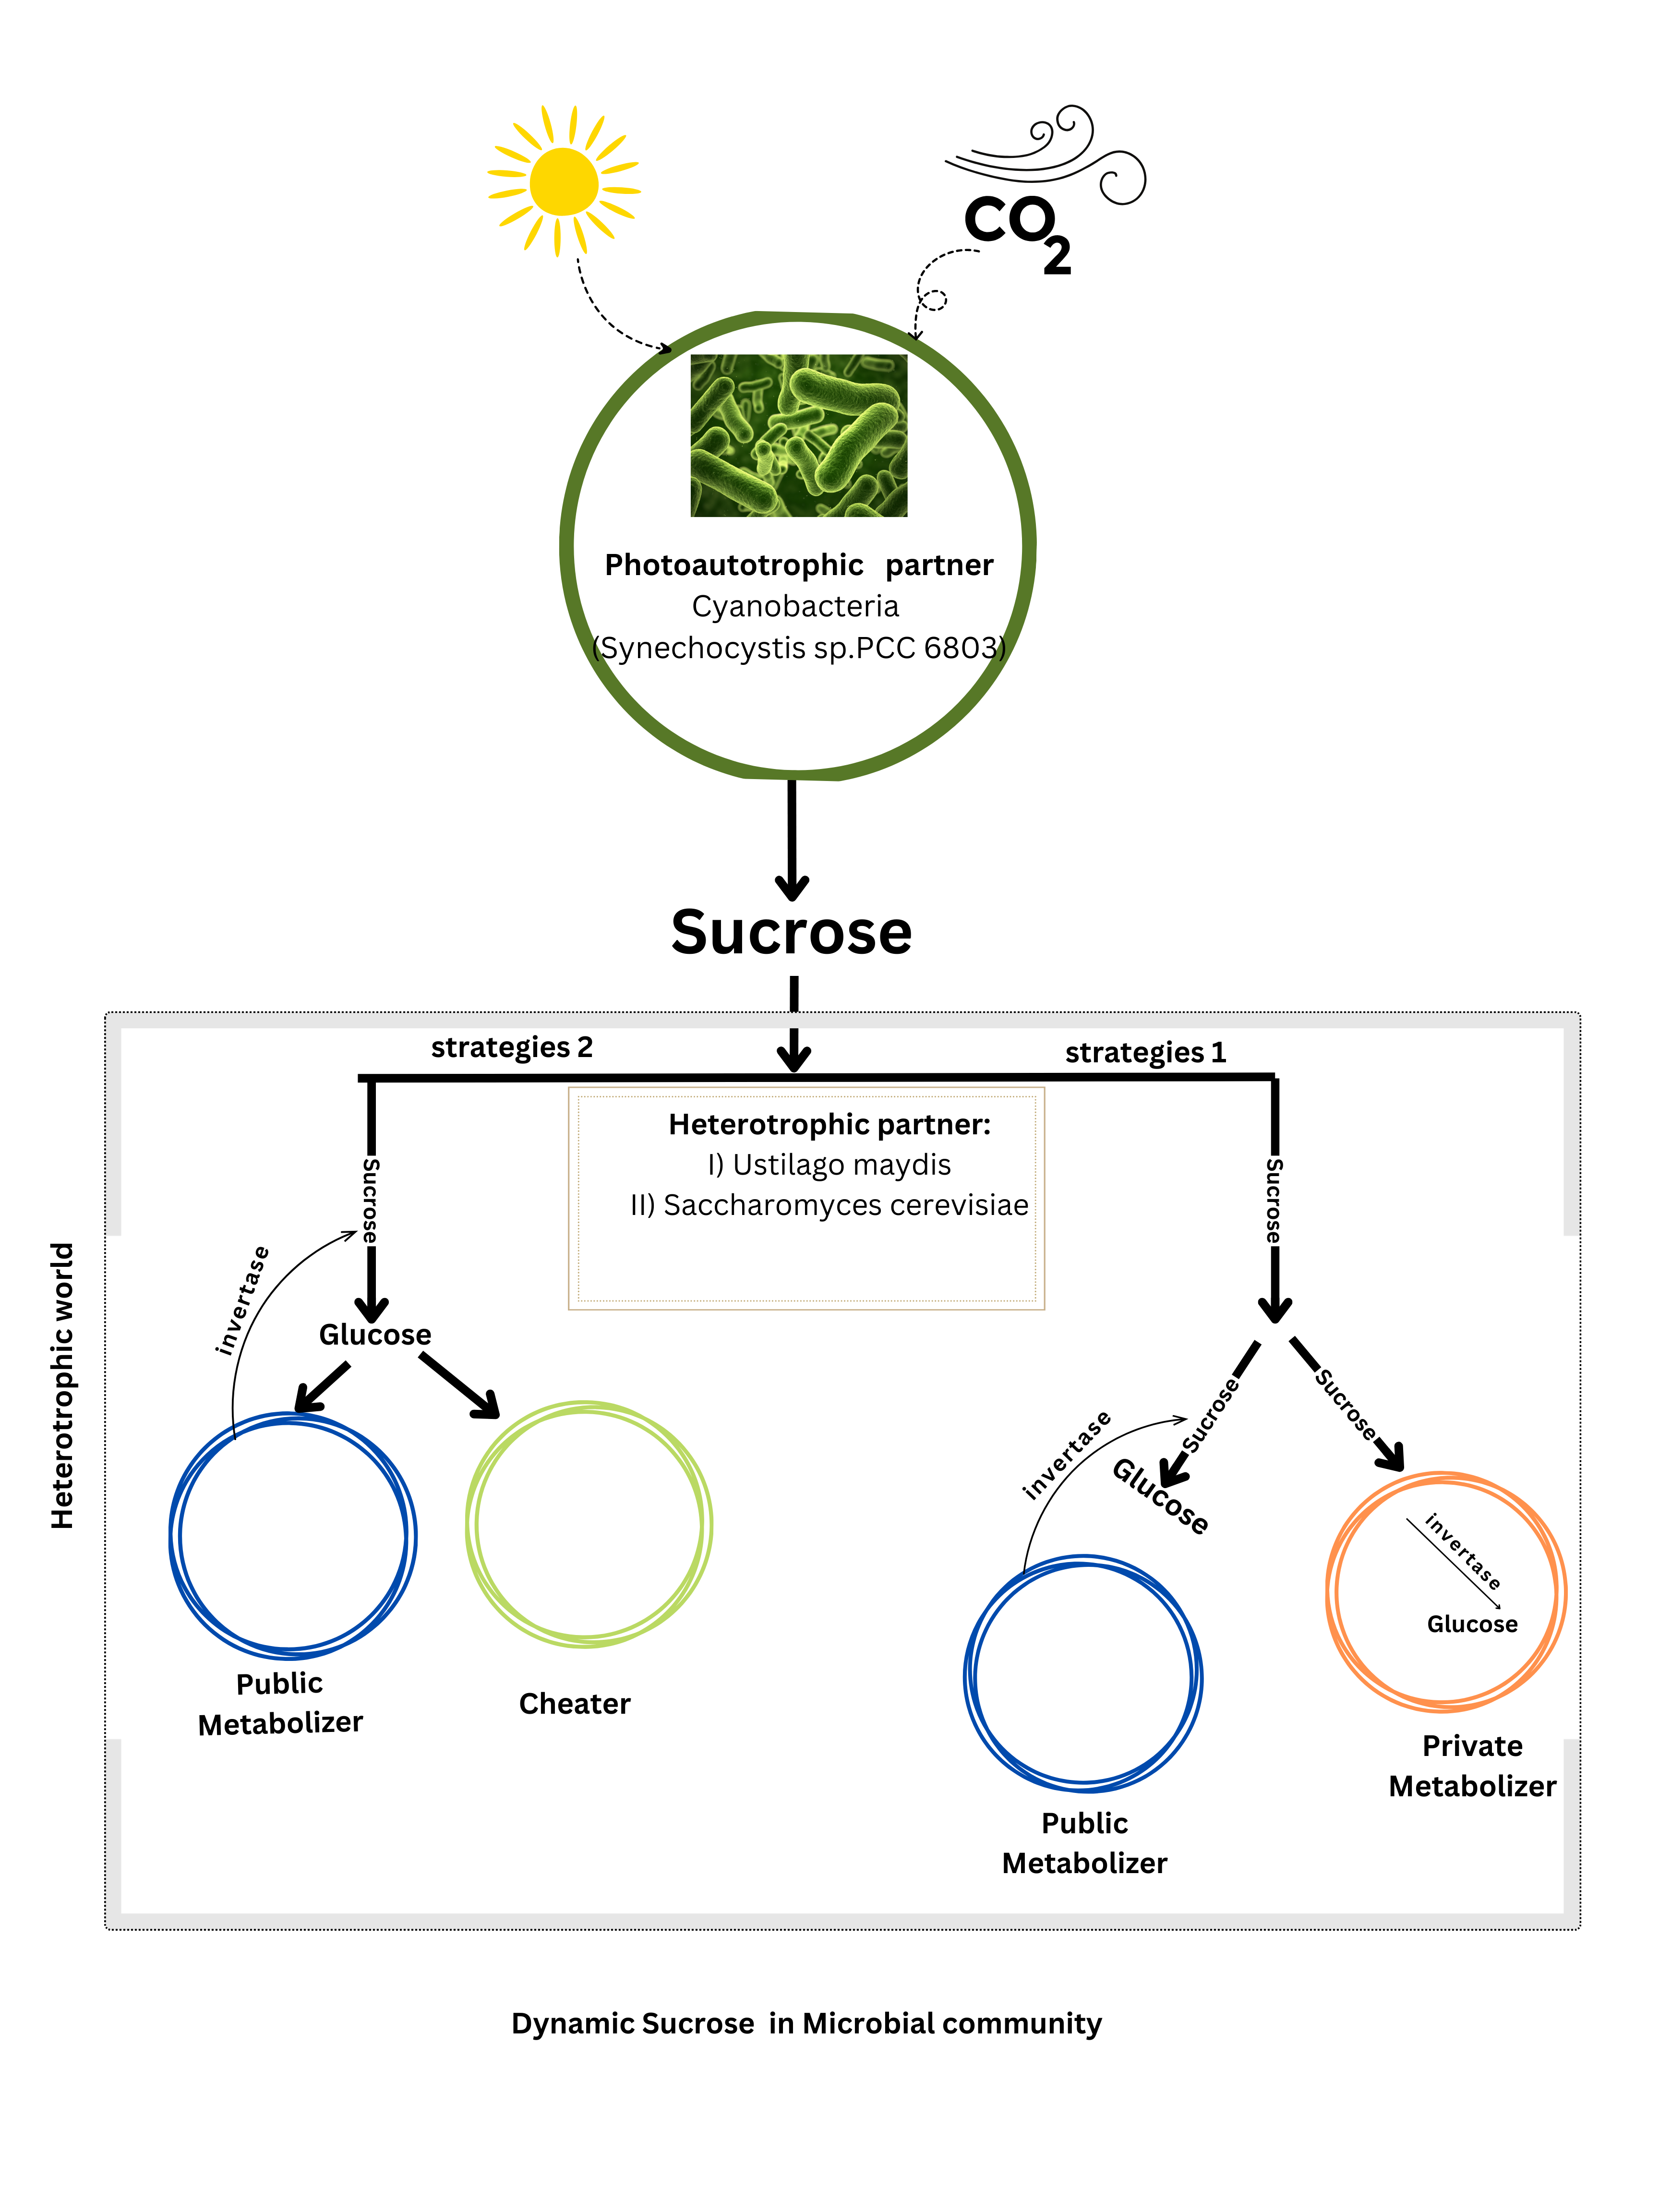

In [ ]:
 In the context of modeling cyanobacteria sucrose production depending on CO_2 and light conditions:

- $(S_i)$: Sucrose production rate.
- $(P_i)$: Photosynthesis rate.
- $(C_i)$: CO_2 uptake rate.
- $(L_i)$: Light absorption efficiency.
- $(E_i)$: Energy storage.

These properties can change over time based on the agent's metabolism and environmental conditions.

###  Environmental Factors

 For cyanobacteria modeling, these include:
- \(CO_2\): The concentration of CO_2 in the environment.
- \(Light\): The intensity and wavelength of light available for photosynthesis.

Environmental factors can vary spatially within the model (e.g., light gradients in water) and temporally (e.g., day-night cycles).

###  Michaelis-Menten kinetics

Agent behaviors are defined by a set of rules that dictate how agents interact with the environment and other agents. For example:
- **Photosynthesis Rule**: The rate of photosynthesis $(P_i)$ for agent $(i)$ can be modeled as a function of light $(L_i)$ and CO_2 availability $(C_i)$, possibly incorporating Michaelis-Menten kinetics for both factors.
  
  $$P_i = f(L_i, C_i) = P_max \frac{L_i }{K_L + L_i} \cdot \frac{C_i}{K_C + C_i}$$
  
  where $ K_L $ and $ K_C $ are half-saturation constants for light and CO_2, respectively.

- **Sucrose Production Rule**: The sucrose production $S $ might be a fraction of the photosynthesis output, adjusted by the cell's energy needs and efficiency factors.
  
  $$ P(t) = k \cdot P_i  $$
  $$ S(t) = k \cdot P_i \cdot t  $$
  where $ k $ is the conversion efficiency of photosynthetic products to sucrose. $ t $ is total time.


### Example Calculation
Consider a scenario where a cyanobacterium is exposed to varying light intensities and CO2 concentrations. 

1. **Light Intensity**: Suppose light intensity varies from 200 to 1000 μmol photons m⁻² s⁻¹.
2. **CO2 Concentration**: Assume CO2 levels range from 400 to 1000 ppm.

Given these conditions, the photosynthesis rate (P) might be described by the following Michaelis-Menten type equation:

$$ P = \frac{P_{max} \cdot I}{K_I + I} \cdot \frac{C}{K_C + C} $$

Where:
- $ P_{max} $ is the maximum photosynthesis rate.
- $ I $ is the light intensity.
- $ K_I $ is the half-saturation constant for light.
- $ C $ is the CO2 concentration.
- $ K_C $ is the half-saturation constant for CO2.

Assuming $ P_{max} = 200 $ μmol O₂ m⁻² s⁻¹, $ K_I = 400 $ μmol photons m⁻² s⁻¹, and $ K_C = 500 $ ppm, the rate of photosynthesis can be calculated for different combinations of light and CO2 levels.

For $ I = 800 $ μmol photons m⁻² s⁻¹ and $ C = 600 $ ppm:

$$ P = \frac{200 \cdot 800}{400 + 800} \cdot \frac{600}{500 + 600} $$
$$ P = \frac{200 \cdot 800}{1200} \cdot \frac{600}{1100} $$
$$ P = \frac{160000}{1200} \cdot \frac{600}{1100} $$
$$ P = 133.33 \cdot 0.545 $$
$$ P ≈ 72.7 \text{ μmol O₂ m⁻² s⁻¹} $$

This photosynthesis rate can be correlated with sucrose production based on known metabolic fluxes in the cyanobacteria.


: 